In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as mpl_anim
from pathlib import Path
import importlib
import time

import sat_tile_stack
importlib.reload(sat_tile_stack) # force Python to re‐read that file

from sat_tile_stack import sattile_stack, sat_mask_array, write_netcdf_from_da, timestack_to_movie



In [6]:
import os
os.environ['LD_LIBRARY_PATH'] = '/share/software/user/open/ffmpeg/7.1/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

Starting movie for tstack_CW2018_1077 → CW2018_1077.mp4


MovieWriter stderr:
[vost#0:0 @ 0x1182a80] Unknown encoder 'h264'
[vost#0:0 @ 0x1182a80] Error selecting an encoder
Error opening output file /oak/stanford/groups/cyaolai/JoshRines/data/CW2018_movies/CW2018_1077.mp4.
Error opening output files: Encoder not found



CalledProcessError: Command '['/share/software/user/open/ffmpeg/7.1/bin/ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '900x900', '-pix_fmt', 'rgba', '-framerate', '1', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-metadata', 'artist=timestack', '-y', PosixPath('/oak/stanford/groups/cyaolai/JoshRines/data/CW2018_movies/CW2018_1077.mp4')]' returned non-zero exit status 8.

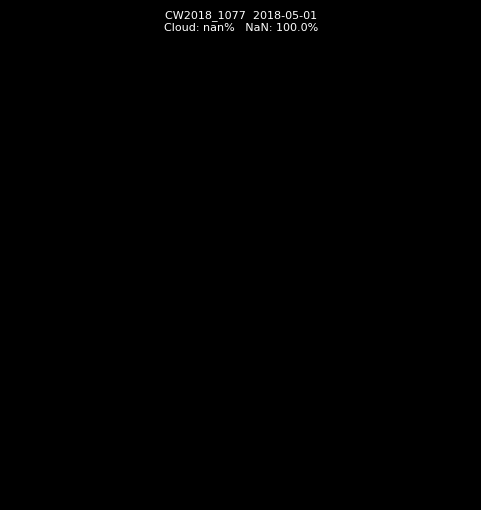

In [7]:
# 1) set your input + output directories
input_dir  = Path("/oak/stanford/groups/cyaolai/JoshRines/data/tstacks/CW2018_tstacks/")             # where all the tstack_*.nc live
output_dir = Path("/oak/stanford/groups/cyaolai/JoshRines/data/CW2018_movies/") # where you want to save .mp4 files
output_dir.mkdir(parents=True, exist_ok=True)          # make sure it exists

# 2) grab every tstack_*.nc into a list
all_files = list(input_dir.glob("tstack_*.nc"))

# 3) sort by the integer after the last underscore, e.g. "tstack_2019cw_42" → 42
def lake_index(path_obj):
    # path_obj.stem is "tstack_2019cw_42"
    # splitting on "_" and taking the last piece gives "42"
    return int(path_obj.stem.split("_")[-1])

all_files_sorted = sorted(all_files, key=lake_index)

start_lakenum = 1077  # Change as needed
all_files_sorted = [
    f for f in all_files_sorted
    if int(f.stem.split("_")[-1]) >= start_lakenum
]

# 4) loop over the sorted list
for nc_file in all_files_sorted:
    stem    = nc_file.stem                   # e.g. "tstack_2019cw_1"
    lakenum = stem.replace("tstack_", "")    # e.g. "2019cw_1"
    out_mp4 = output_dir / f"{lakenum}.mp4"

    print(f"Starting movie for {stem} → {out_mp4.name}")
    t0 = time.time()

    timestack_to_movie(
        nc_path = nc_file,
        bands   = ("B04", "B03", "B02"),  # true-color
        fps     = 1,
        outfile = out_mp4
    )

    t1 = time.time()
    elapsed = t1 - t0
    print(f"Finished {out_mp4.name} in {elapsed:.1f} seconds.\n")
    
    
    